# ADME/T 예측 — 다중 엔드포인트

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fourmodern/2025_aidrugdiscovery/blob/main/20260825/notebooks/03_admet_prediction.ipynb)

**AI 신약개발 실무 실습 · 하나의 표현/모델 기계로 여러 ADME/T 엔드포인트 예측하기**

신약 후보의 실패 원인 중 상당수는 효능이 아니라 **ADME/T**(흡수 Absorption · 분포 Distribution · 대사 Metabolism · 배설 Excretion · 독성 Toxicity)입니다. 이 노트북은 **동일한 분자 표현(RDKit 기술자 + Morgan/ECFP)과 동일한 모델군(랜덤포레스트)** 을 그대로 두고, **엔드포인트와 평가지표만 바꿔** 두 가지 대표 과제를 풉니다.

| 엔드포인트 | ADME/T 축 | 문제 유형 | 대표 지표 |
|---|---|---|---|
| **BBBP** — 혈뇌장벽 투과 | Distribution / Toxicity | **분류** (불균형) | ROC-AUC, 정확도 |
| **Lipophilicity** — logD7.4 | Absorption / Distribution | **회귀** | R², RMSE |

**오늘의 흐름**
1. **표현(공통)** — SMILES → RDKit 분자 기술자 + Morgan/ECFP(radius=2, 2048비트). RDKit 유효 분자만 사용.
2. **BBBP (분류)** — ECFP + RandomForestClassifier(class_weight="balanced"). ROC-AUC·정확도·5-fold Stratified CV. ROC 곡선 + 혼동행렬.
3. **Lipophilicity (회귀)** — 기술자+ECFP + RandomForestRegressor. R²/RMSE·5-fold CV. 예측-실측 산점도 + 잔차.
4. **정리** — 두 엔드포인트 지표 요약표 + "표현·모델은 같고 엔드포인트/지표만 다르다".

> ⚠️ **무-날조 원칙**: 데이터는 실제 공개 측정/주석값이며, 모든 성능 수치(ROC-AUC·R²·RMSE 등)는 이 노트북이 **실제로 계산**한 값입니다. 어떤 지표도 사람이 임의로 적지 않았습니다.
> 🖥️ Google Colab CPU 런타임에서 수 분 내 완료됩니다. 별도 GPU 불필요.

## 0. 설치 & 환경 (Colab)

In [1]:
!pip install -q rdkit scikit-learn
# 한글 폰트 설치(그래프 라벨 깨짐 방지)
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1 || true

import matplotlib as mpl, matplotlib.font_manager as fm
_kf = [f for f in fm.findSystemFonts() if "Nanum" in f]
for _f in _kf:
    fm.fontManager.addfont(_f)
if _kf:
    mpl.rcParams["font.family"] = "NanumGothic"
mpl.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지
mpl.rcParams["figure.dpi"] = 120             # 해상도 dpi >= 120

# 색맹 친화(colorblind-safe) 팔레트 — Okabe-Ito 계열
CB = {"blue":"#0072B2", "orange":"#E69F00", "green":"#009E73",
      "red":"#D55E00", "purple":"#CC79A7", "gray":"#666666"}

import platform
print("python", platform.python_version(), "| 한글폰트:", "OK" if _kf else "기본(미설치)")


python 3.12.3 | 한글폰트: 기본(미설치)


## 1. 공통 표현 — SMILES → 분자 기술자 + Morgan/ECFP

두 엔드포인트가 **완전히 같은 표현 함수**를 공유합니다. 이것이 이 실습의 핵심입니다 — 데이터와 목표(엔드포인트)만 바뀔 뿐, 분자를 숫자로 바꾸는 방식은 동일합니다.

- **분자 기술자**: 물성·위상 기반의 해석 가능한 소수 차원 (MW·logP·TPSA·HBD/HBA·회전결합·방향족고리 등)
- **Morgan/ECFP 지문**: 원형 부분구조(radius=2 ≈ ECFP4)를 2048비트 벡터로 인코딩 (고차원·강력)

**RDKit로 파싱되는 유효 분자만** 남깁니다(무효 SMILES 제거).

In [2]:
import pandas as pd, numpy as np
from rdkit import Chem
from rdkit import RDLogger; RDLogger.DisableLog("rdApp.*")   # RDKit 경고 억제
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator

# --- (a) 분자 기술자: 해석 가능한 물성 벡터 ---
DESC_NAMES = ["MW","logP","TPSA","HBD","HBA","RotB","AromRings","Rings","FracCSP3","HeavyAtoms"]
def descriptors(m):
    return [
        Descriptors.MolWt(m), Crippen.MolLogP(m), rdMolDescriptors.CalcTPSA(m),
        Lipinski.NumHDonors(m), Lipinski.NumHAcceptors(m),
        rdMolDescriptors.CalcNumRotatableBonds(m), rdMolDescriptors.CalcNumAromaticRings(m),
        rdMolDescriptors.CalcNumRings(m), Descriptors.FractionCSP3(m), m.GetNumHeavyAtoms(),
    ]

# --- (b) Morgan/ECFP 지문 (radius=2, 2048비트) ---
mfp = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
def ecfp(m):
    return list(mfp.GetFingerprint(m))

def load_smiles(url, smiles_col, target_col):
    """CSV를 읽어 RDKit 유효 분자만 남기고 mol/기술자/ECFP를 반환."""
    df = pd.read_csv(url)
    df = df.rename(columns={smiles_col: "smiles", target_col: "target"})[["smiles","target"]]
    df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
    n0 = len(df)
    df = df[df["mol"].notnull()].reset_index(drop=True)   # 유효 분자만
    X_desc = np.array([descriptors(m) for m in df["mol"]])
    X_fp   = np.array([ecfp(m) for m in df["mol"]])
    X_both = np.hstack([X_desc, X_fp])                    # 기술자 + ECFP 결합
    print(f"  로드 {n0}개 → 유효 {len(df)}개 (무효 SMILES {n0-len(df)}개 제거)")
    print(f"  기술자 {X_desc.shape} | ECFP {X_fp.shape} | 결합 {X_both.shape}")
    return df, X_desc, X_fp, X_both

print("공통 표현 함수 준비 완료 (descriptors / ecfp / load_smiles)")


공통 표현 함수 준비 완료 (descriptors / ecfp / load_smiles)


## 2. 엔드포인트 ① BBBP — 혈뇌장벽 투과 (분류 · Distribution/T)

**혈뇌장벽(BBB) 투과**는 중추신경계(CNS) 약물에는 필수, 말초 약물에는 회피 대상인 **분포(Distribution)** 특성입니다. 데이터: MoleculeNet **BBBP** (Martins et al. 2012), 라벨 `p_np` (1=투과, 0=비투과).

투과/비투과 클래스가 **불균형**이므로 정확도만으로는 오해할 수 있어 **ROC-AUC**를 주지표로 사용하고, 분류기에 `class_weight="balanced"`를 적용합니다.

In [3]:
# BBBP 로드 (실제 공개 데이터) — §1의 공통 표현 사용
BBBP_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
print("[BBBP] 혈뇌장벽 투과 (분류)")
bbbp, Xb_desc, Xb_fp, Xb_both = load_smiles(BBBP_URL, smiles_col="smiles", target_col="p_np")
yb = bbbp["target"].astype(int).values

u, c = np.unique(yb, return_counts=True)
dist = dict(zip(u.tolist(), c.tolist()))
print("클래스 분포 (0=비투과, 1=투과):", dist,
      f"| 투과 비율 {yb.mean()*100:.1f}%  → 불균형이므로 ROC-AUC 주지표")


[BBBP] 혈뇌장벽 투과 (분류)


  로드 2050개 → 유효 2039개 (무효 SMILES 11개 제거)
  기술자 (2039, 10) | ECFP (2039, 2048) | 결합 (2039, 2058)
클래스 분포 (0=비투과, 1=투과): {0: 479, 1: 1560} | 투과 비율 76.5%  → 불균형이므로 ROC-AUC 주지표


In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve

# 표현: ECFP 지문 사용 (구조 기반 분류에 강력)
Xtr, Xte, ytr, yte = train_test_split(Xb_fp, yb, test_size=0.2,
                                      random_state=42, stratify=yb)
clf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1,
                             class_weight="balanced").fit(Xtr, ytr)

proba = clf.predict_proba(Xte)[:, 1]
pred  = (proba >= 0.5).astype(int)
bbbp_auc = roc_auc_score(yte, proba)
bbbp_acc = accuracy_score(yte, pred)

# 5-fold Stratified CV ROC-AUC (분할 우연성 배제, 클래스 비율 유지)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(
    RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced"),
    Xb_fp, yb, cv=skf, scoring="roc_auc")
bbbp_cv_auc, bbbp_cv_std = cv_auc.mean(), cv_auc.std()

print(f"[BBBP · ECFP+RF]")
print(f"  테스트 ROC-AUC = {bbbp_auc:.3f} | 정확도 = {bbbp_acc:.3f}")
print(f"  5-fold Stratified CV ROC-AUC = {bbbp_cv_auc:.3f} ± {bbbp_cv_std:.3f}  (무작위 기준 0.5)")


[BBBP · ECFP+RF]
  테스트 ROC-AUC = 0.938 | 정확도 = 0.917
  5-fold Stratified CV ROC-AUC = 0.921 ± 0.009  (무작위 기준 0.5)


/tmp/ipykernel_2933374/4018674556.py:21: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/4018674556.py:21: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/4018674556.py:21: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/4018674556.py:21: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/4018674556.py:21: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/4018674556.py:21: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/4018674556.py:21: Us

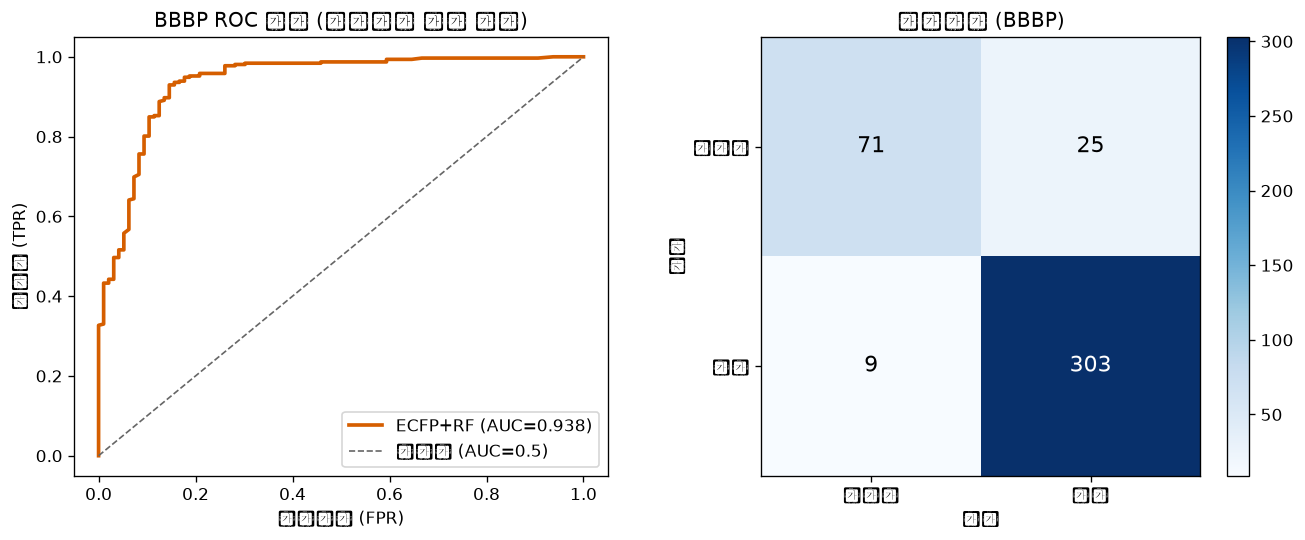

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
# (1) ROC 곡선
fpr, tpr, _ = roc_curve(yte, proba)
ax[0].plot(fpr, tpr, color=CB["red"], lw=2.2, label=f"ECFP+RF (AUC={bbbp_auc:.3f})")
ax[0].plot([0, 1], [0, 1], "--", color=CB["gray"], lw=1, label="무작위 (AUC=0.5)")
ax[0].set_xlabel("위양성률 (FPR)"); ax[0].set_ylabel("민감도 (TPR)")
ax[0].set_title("BBBP ROC 곡선 (혈뇌장벽 투과 분류)")
ax[0].legend(loc="lower right")
# (2) 혼동행렬
cm = confusion_matrix(yte, pred)
im = ax[1].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax[1].text(j, i, int(v), ha="center", va="center", fontsize=13,
               color="white" if v > cm.max()/2 else "black")
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["비투과", "투과"])
ax[1].set_yticks([0, 1]); ax[1].set_yticklabels(["비투과", "투과"])
ax[1].set_xlabel("예측"); ax[1].set_ylabel("실제"); ax[1].set_title("혼동행렬 (BBBP)")
plt.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()


### 2-1. 분자 구조로 보는 BBBP — 투과 vs 비투과, 오분류, 그리고 실제 약물 검증

숫자 지표를 넘어 **실제 분자 구조**를 눈으로 확인합니다. 데이터셋의 투과/비투과 대표 구조,
모델이 **틀린 분자**(FP/FN), 예측확률 분포와 PR 곡선, 마지막으로 **잘 알려진 약물**로 분류기를 검증합니다.
모든 구조는 RDKit로 렌더한 **실제 데이터셋 분자**이며, 확률은 학습된 분류기가 **실제 계산**한 값입니다.

BBBP 예시 구조 — 위줄 6개 = 투과(양성), 아래줄 6개 = 비투과(음성)


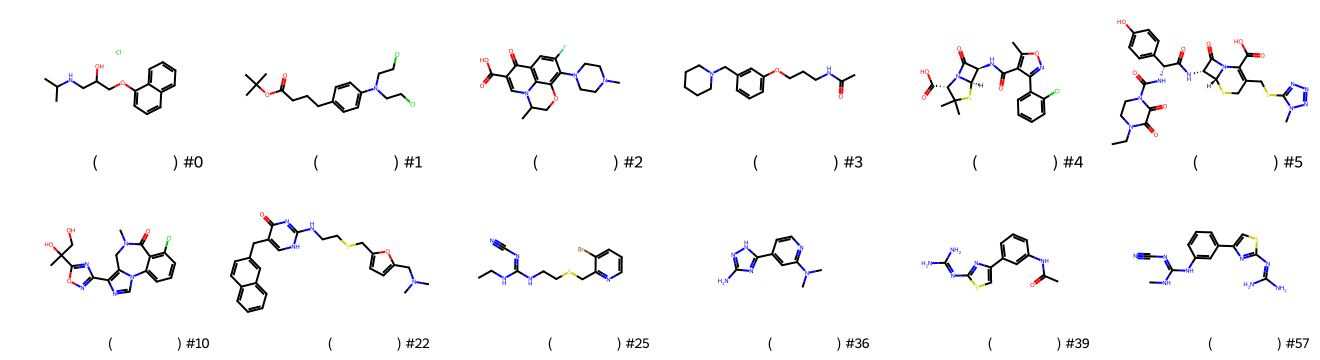

In [6]:
from rdkit.Chem import Draw
from IPython.display import display

# 혈뇌장벽 투과(양성) 6개 + 비투과(음성) 6개 — 실제 BBBP 데이터셋 분자 구조
pos_idx = list(bbbp.index[bbbp["target"] == 1][:6])
neg_idx = list(bbbp.index[bbbp["target"] == 0][:6])
sel  = pos_idx + neg_idx
mols = [bbbp.loc[i, "mol"] for i in sel]
legs = [f"투과(양성) #{i}" for i in pos_idx] + [f"비투과(음성) #{i}" for i in neg_idx]
print("BBBP 예시 구조 — 위줄 6개 = 투과(양성), 아래줄 6개 = 비투과(음성)")
img = Draw.MolsToGridImage(mols, molsPerRow=6, subImgSize=(220, 180),
                           legends=legs, useSVG=False)
display(img)

오분류 분자: 총 34개 (FP=25, FN=9) — 확신 높은 오류 최대 12개 표시


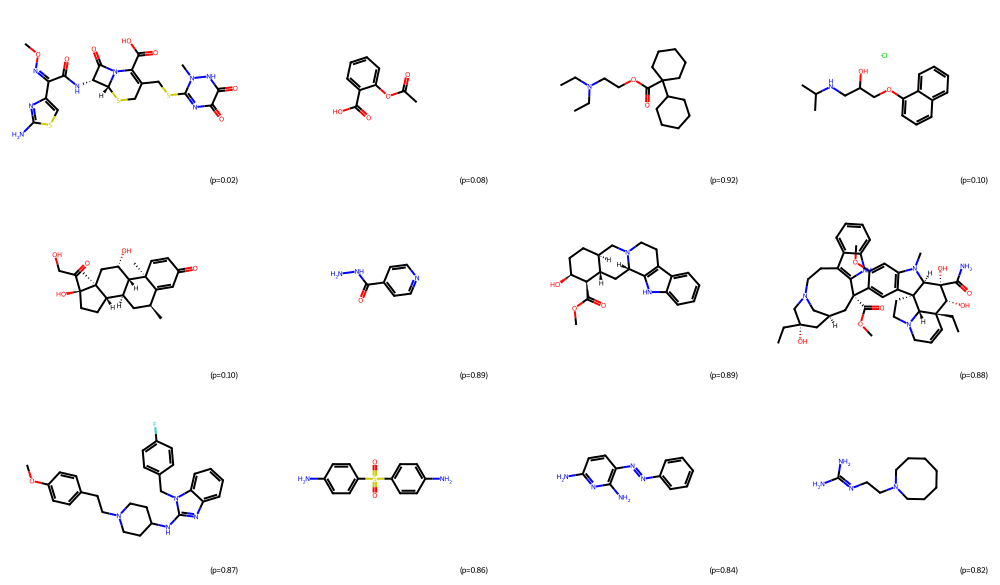

In [7]:
# 테스트셋 오분류 분자 (FP: 실제 비투과→예측 투과 / FN: 실제 투과→예측 비투과)
# cell §2의 split 을 인덱스로 재현하여 Xte/proba/pred 와 정렬을 맞춘다 (동일 random_state·stratify).
idx_all = np.arange(len(yb))
_, idx_te = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=yb)
assert np.array_equal(yb[idx_te], yte), "테스트 정렬 불일치"   # proba/pred 와 순서 일치 확인

mis_all = np.where(pred != yte)[0]
n_fp = int(np.sum((pred == 1) & (yte == 0)))
n_fn = int(np.sum((pred == 0) & (yte == 1)))
# 확률이 0.5에서 먼 순(=모델이 '자신있게' 틀린 순)으로 정렬, 최대 12개 표시
mis = mis_all[np.argsort(-np.abs(proba[mis_all] - 0.5))][:12]
lab = {0: "비투과", 1: "투과"}
mm  = [bbbp.loc[idx_te[k], "mol"] for k in mis]
legs = [f"실제 {lab[yte[k]]}→예측 {lab[pred[k]]} (p={proba[k]:.2f})" for k in mis]
print(f"오분류 분자: 총 {len(mis_all)}개 (FP={n_fp}, FN={n_fn}) — 확신 높은 오류 최대 12개 표시")
img = Draw.MolsToGridImage(mm, molsPerRow=4, subImgSize=(250, 195),
                           legends=legs, useSVG=False)
display(img)

/tmp/ipykernel_2933374/2856058504.py:17: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/2856058504.py:17: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/2856058504.py:17: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/2856058504.py:17: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/2856058504.py:17: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/2856058504.py:17: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/2856058504.py:17: User

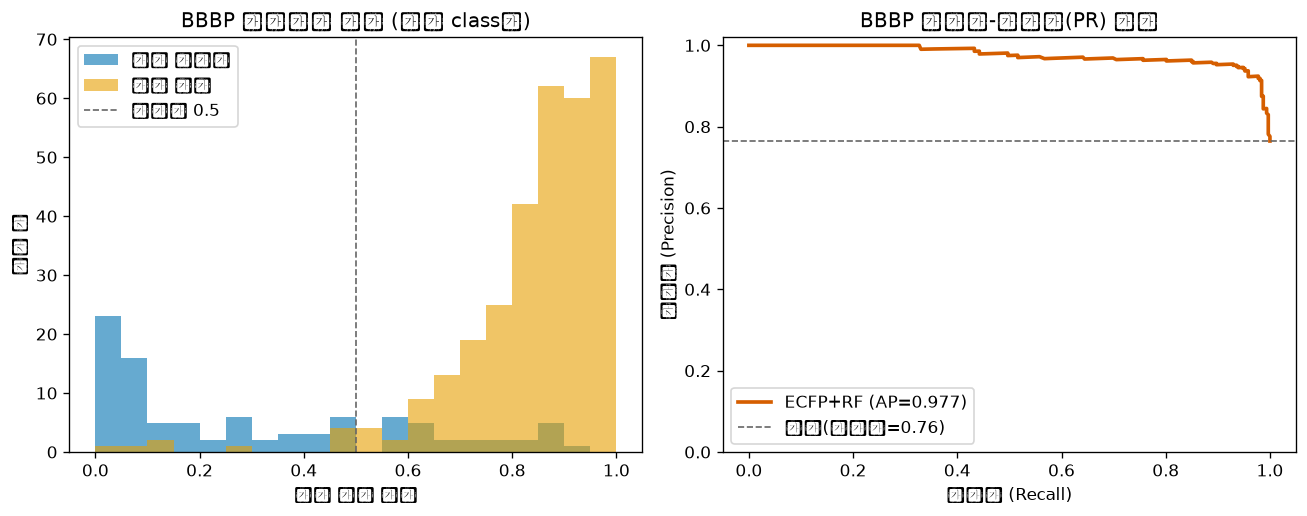

In [8]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
# (1) 예측확률 분포 — 실제 class별 히스토그램 (분리도가 좋을수록 두 봉우리가 갈라짐)
ax[0].hist(proba[yte == 0], bins=20, range=(0, 1), alpha=0.6, color=CB["blue"],  label="실제 비투과")
ax[0].hist(proba[yte == 1], bins=20, range=(0, 1), alpha=0.6, color=CB["orange"], label="실제 투과")
ax[0].axvline(0.5, color=CB["gray"], ls="--", lw=1, label="임계값 0.5")
ax[0].set_xlabel("예측 투과 확률"); ax[0].set_ylabel("분자 수")
ax[0].set_title("BBBP 예측확률 분포 (실제 class별)"); ax[0].legend()
# (2) 정밀도-재현율(PR) 곡선 — 불균형 데이터에서 ROC 보완
prec, rec, _ = precision_recall_curve(yte, proba)
ap = average_precision_score(yte, proba)
ax[1].plot(rec, prec, color=CB["red"], lw=2.2, label=f"ECFP+RF (AP={ap:.3f})")
ax[1].axhline(yte.mean(), color=CB["gray"], ls="--", lw=1, label=f"기저(투과율={yte.mean():.2f})")
ax[1].set_xlabel("재현율 (Recall)"); ax[1].set_ylabel("정밀도 (Precision)")
ax[1].set_ylim(0, 1.02); ax[1].set_title("BBBP 정밀도-재현율(PR) 곡선"); ax[1].legend(loc="lower left")
plt.tight_layout(); plt.show()

### 2-2. 실제 화합물로 검증 — 알려진 CNS 약물의 BBB 투과 확률

학습된 분류기를 **널리 알려진 약물**에 적용합니다. 중추신경계(CNS)에 작용하려면 BBB **투과**가 필요하고
(카페인·디아제팜·플루옥세틴 등), 말초/친수성 약물은 투과가 낮은 경향입니다. 각 분자는 §1의 **공통 표현 함수(ECFP)**
로 인코딩해 분류기가 확률을 계산합니다. **데이터셋에 실제로 존재하는 분자는 실제 라벨도 함께 표시**(진짜 검증),
없는 분자는 **예측만** 표시합니다(날조 없음).

=== 실제 약물 BBB 투과 예측 (확률은 학습된 분류기의 실계산값) ===
                약물  예측확률  예측        기대경향    데이터셋검증
    Caffeine (카페인) 0.926  투과  CNS(투과 경향)  실제=투과·일치
   Diazepam (디아제팜) 0.998  투과  CNS(투과 경향)  실제=투과·일치
Fluoxetine (플루옥세틴) 0.887  투과  CNS(투과 경향)  실제=투과·일치
    Nicotine (니코틴) 0.980  투과  CNS(투과 경향)  실제=투과·일치
   Atenolol (아테놀롤) 0.107 비투과  말초(비투과 경향) 실제=비투과·일치
 Loratadine (로라타딘) 0.288 비투과  말초(비투과 경향) 실제=비투과·일치
  Sulpiride (설피리드) 0.988  투과  말초(비투과 경향)  실제=투과·일치
    Dopamine (도파민) 0.043 비투과 친수성(비투과 경향) 실제=비투과·일치


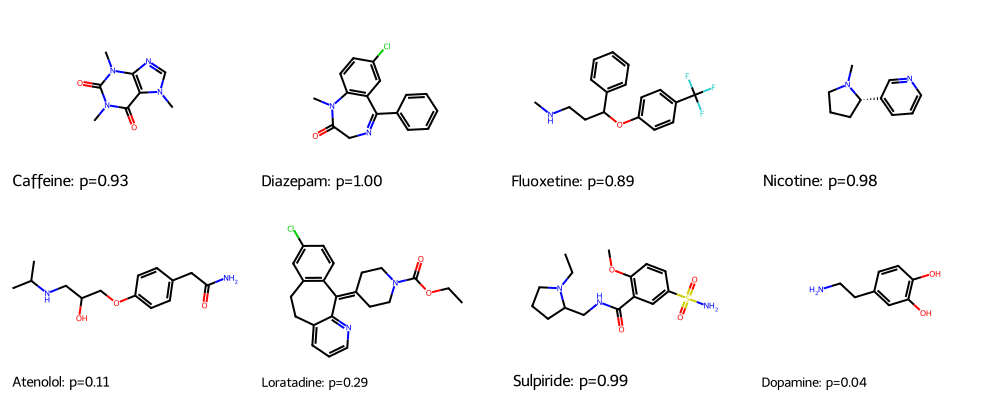

In [9]:
# 잘 알려진 약물 — (이름, SMILES, 기대 경향). CNS 약물은 투과 경향, 말초/친수성은 비투과 경향.
bbbp_probe = [
    ("Caffeine (카페인)",      "Cn1cnc2c1c(=O)n(C)c(=O)n2C",              "CNS(투과 경향)"),
    ("Diazepam (디아제팜)",    "CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21",     "CNS(투과 경향)"),
    ("Fluoxetine (플루옥세틴)","CNCCC(Oc1ccc(C(F)(F)F)cc1)c1ccccc1",       "CNS(투과 경향)"),
    ("Nicotine (니코틴)",      "CN1CCC[C@H]1c1cccnc1",                     "CNS(투과 경향)"),
    ("Atenolol (아테놀롤)",    "CC(C)NCC(O)COc1ccc(CC(N)=O)cc1",           "말초(비투과 경향)"),
    ("Loratadine (로라타딘)",  "CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc3cccnc32)CC1", "말초(비투과 경향)"),
    ("Sulpiride (설피리드)",   "CCN1CCCC1CNC(=O)c1cc(S(N)(=O)=O)ccc1OC",   "말초(비투과 경향)"),
    ("Dopamine (도파민)",      "NCCc1ccc(O)c(O)c1",                        "친수성(비투과 경향)"),
]

# 데이터셋에 실제로 존재하는지 대조하기 위한 canonical SMILES → 실제 라벨 매핑
def _canon(s):
    m = Chem.MolFromSmiles(s)
    return Chem.MolToSmiles(m) if m else None
bbbp_lookup = {}
for s, t in zip(bbbp["smiles"], bbbp["target"]):
    cs = _canon(s)
    if cs is not None:
        bbbp_lookup.setdefault(cs, int(t))

rows, mols, legs = [], [], []
for name, smi, hint in bbbp_probe:
    m = Chem.MolFromSmiles(smi)
    if m is None:
        continue
    prob = float(clf.predict_proba(np.array([ecfp(m)]))[0, 1])   # 학습된 분류기의 실제 예측
    call = "투과" if prob >= 0.5 else "비투과"
    actual = bbbp_lookup.get(Chem.MolToSmiles(m))                # 데이터셋 실제 라벨(있으면)
    if actual is None:
        tag = "예측만(데이터셋 외)"
    else:
        tag = f"실제={'투과' if actual==1 else '비투과'}·" + ("일치" if actual == (prob>=0.5) else "불일치")
    rows.append({"약물": name, "예측확률": round(prob, 3), "예측": call,
                 "기대경향": hint, "데이터셋검증": tag})
    mols.append(m)
    legs.append(f"{name.split(' (')[0]}: p={prob:.2f}→{call}")

probe_df = pd.DataFrame(rows)
print("=== 실제 약물 BBB 투과 예측 (확률은 학습된 분류기의 실계산값) ===")
print(probe_df.to_string(index=False))
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(250, 200),
                           legends=legs, useSVG=False)
display(img)

## 3. 엔드포인트 ② Lipophilicity — logD7.4 (회귀 · ADME)

**친유성(logD7.4)** 은 막 투과·용해도·분포·대사에 두루 영향을 주는 핵심 **흡수/분포(A/D)** 물성입니다. 데이터: MoleculeNet **Lipophilicity** (ChEMBL 유래 실험 logD7.4), 타깃 컬럼 `exp`.

이제 **엔드포인트(연속값 logD)와 지표(R²/RMSE)만 바뀌고**, 표현 함수와 모델군(랜덤포레스트)은 §1·§2와 동일합니다. 여기서는 기술자와 ECFP를 결합한 표현을 사용합니다.

In [10]:
LIPO_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/Lipophilicity.csv"
print("[Lipophilicity] logD7.4 (회귀)")
lipo, Xl_desc, Xl_fp, Xl_both = load_smiles(LIPO_URL, smiles_col="smiles", target_col="exp")
yl = lipo["target"].astype(float).values
print(f"logD7.4 범위: {yl.min():.2f} ~ {yl.max():.2f} | 평균 {yl.mean():.2f} ± {yl.std():.2f}")


[Lipophilicity] logD7.4 (회귀)


  로드 4200개 → 유효 4200개 (무효 SMILES 0개 제거)
  기술자 (4200, 10) | ECFP (4200, 2048) | 결합 (4200, 2058)
logD7.4 범위: -1.50 ~ 4.50 | 평균 2.19 ± 1.20


In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 표현: 기술자 + ECFP 결합
Xtr, Xte, ytr, yte = train_test_split(Xl_both, yl, test_size=0.2, random_state=42)
reg = RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1).fit(Xtr, ytr)
p = reg.predict(Xte)

lipo_r2   = r2_score(yte, p)
lipo_rmse = mean_squared_error(yte, p) ** 0.5   # RMSE = MSE ** 0.5

# 5-fold CV (R²) — 분할 우연성 배제
cv_r2 = cross_val_score(
    RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1),
    Xl_both, yl, cv=5, scoring="r2")
lipo_cv_r2, lipo_cv_std = cv_r2.mean(), cv_r2.std()

print(f"[Lipophilicity · 기술자+ECFP+RF]")
print(f"  테스트 R² = {lipo_r2:.3f} | RMSE = {lipo_rmse:.3f} (log unit)")
print(f"  5-fold CV R² = {lipo_cv_r2:.3f} ± {lipo_cv_std:.3f}")


[Lipophilicity · 기술자+ECFP+RF]
  테스트 R² = 0.673 | RMSE = 0.695 (log unit)
  5-fold CV R² = 0.666 ± 0.009


/tmp/ipykernel_2933374/3435165704.py:15: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/3435165704.py:15: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/3435165704.py:15: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/3435165704.py:15: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/3435165704.py:15: UserWarning: Glyph 48317 (\N{HANGUL SYLLABLE BYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/3435165704.py:15: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/3435165704.py:15: Use

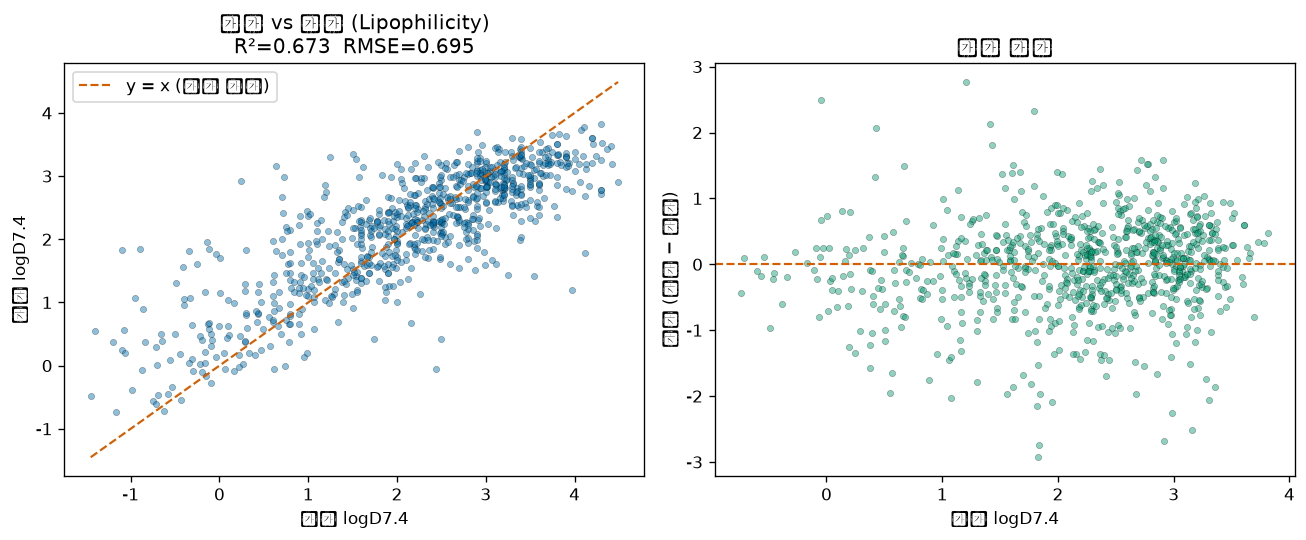

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
# (1) 예측 vs 실측 산점도 + y=x
lim = [min(yte.min(), p.min()), max(yte.max(), p.max())]
ax[0].scatter(yte, p, s=14, alpha=0.45, c=CB["blue"], edgecolor="k", linewidth=0.3)
ax[0].plot(lim, lim, "--", color=CB["red"], lw=1.3, label="y = x (완벽 예측)")
ax[0].set_xlabel("실측 logD7.4"); ax[0].set_ylabel("예측 logD7.4")
ax[0].set_title(f"예측 vs 실측 (Lipophilicity)\nR²={lipo_r2:.3f}  RMSE={lipo_rmse:.3f}")
ax[0].legend(loc="upper left")
# (2) 잔차 플롯
resid = yte - p
ax[1].scatter(p, resid, s=14, alpha=0.45, c=CB["green"], edgecolor="k", linewidth=0.3)
ax[1].axhline(0, color=CB["red"], ls="--", lw=1.3)
ax[1].set_xlabel("예측 logD7.4"); ax[1].set_ylabel("잔차 (실측 − 예측)")
ax[1].set_title("잔차 플롯")
plt.tight_layout(); plt.show()


### 3-1. 분자 구조로 보는 Lipophilicity — 친유성 극단, 예측 오차, 실제 약물 검증

logD7.4가 **가장 높은(친유성)·가장 낮은(친수성)** 실제 분자 구조, 회귀 모델이 **가장 크게 틀린** 분자,
예측-실측 밀도(hexbin)와 잔차 분포, 그리고 **유명 약물의 logD 예측**을 확인합니다.
데이터셋 분자에는 **실험 logD(exp)** 를 함께 표시합니다(진짜 검증).

Lipophilicity 극단 구조 — 위줄 = logD 최고(친유성) 6개, 아래줄 = logD 최저(친수성) 6개 (값=실험 exp)


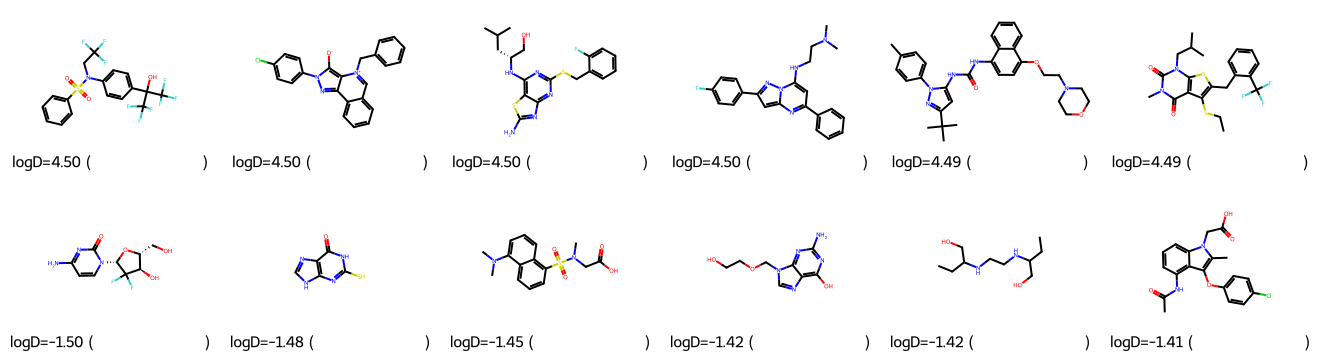

In [13]:
# logD7.4 최고(친유성) 6개 + 최저(친수성) 6개 — 실제 Lipophilicity 데이터셋 분자
order    = np.argsort(yl)
low_idx  = list(order[:6])
high_idx = list(order[-6:][::-1])
sel  = high_idx + low_idx
mols = [lipo.loc[i, "mol"] for i in sel]
legs = [f"logD={yl[i]:.2f} (친유성)" for i in high_idx] + \
       [f"logD={yl[i]:.2f} (친수성)" for i in low_idx]
print("Lipophilicity 극단 구조 — 위줄 = logD 최고(친유성) 6개, 아래줄 = logD 최저(친수성) 6개 (값=실험 exp)")
img = Draw.MolsToGridImage(mols, molsPerRow=6, subImgSize=(220, 180),
                           legends=legs, useSVG=False)
display(img)

Lipophilicity 예측 최악 잔차 분자 8개 — 실측 exp vs 모델 예측 (모두 실계산값)


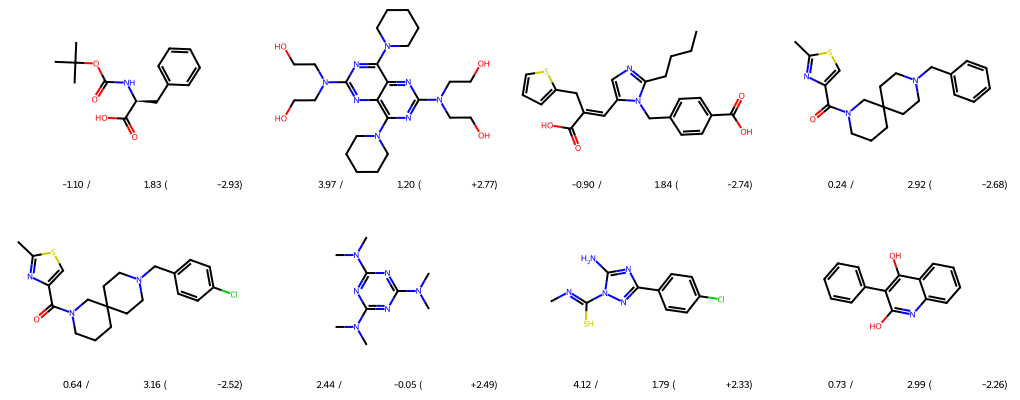

In [14]:
# 예측 최악(잔차 절대값 최대) 분자 — 회귀 모델이 크게 벗어난 케이스
idx_te_l = train_test_split(np.arange(len(yl)), test_size=0.2, random_state=42)[1]
assert np.allclose(yl[idx_te_l], yte), "Lipo 테스트 정렬 불일치"   # cell §3 의 yte 와 순서 일치
worst = np.argsort(-np.abs(resid))[:8]
mm    = [lipo.loc[idx_te_l[k], "mol"] for k in worst]
legs  = [f"실측 {yte[k]:.2f} / 예측 {p[k]:.2f} (잔차 {resid[k]:+.2f})" for k in worst]
print("Lipophilicity 예측 최악 잔차 분자 8개 — 실측 exp vs 모델 예측 (모두 실계산값)")
img = Draw.MolsToGridImage(mm, molsPerRow=4, subImgSize=(255, 200),
                           legends=legs, useSVG=False)
display(img)

/tmp/ipykernel_2933374/3149429408.py:15: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/3149429408.py:15: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/3149429408.py:15: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/3149429408.py:15: UserWarning: Glyph 48128 (\N{HANGUL SYLLABLE MIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/3149429408.py:15: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/3149429408.py:15: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/3149429408.py:15: UserWa

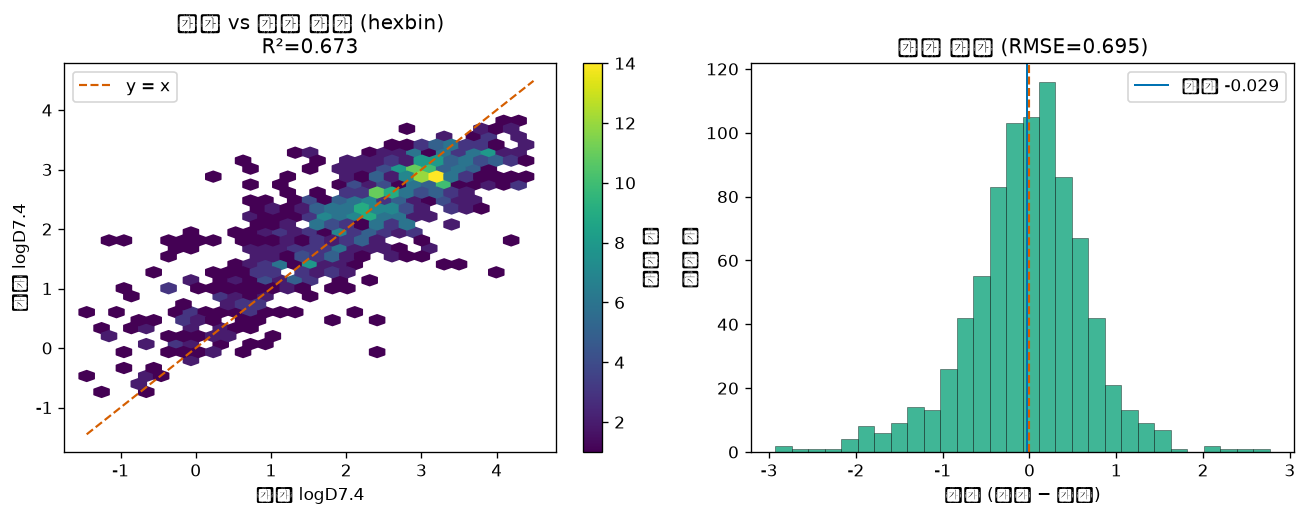

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
# (1) 예측-실측 밀도(hexbin) — 점 겹침이 심한 중앙부를 밀도로 표현
hb  = ax[0].hexbin(yte, p, gridsize=30, cmap="viridis", mincnt=1)
lim = [min(yte.min(), p.min()), max(yte.max(), p.max())]
ax[0].plot(lim, lim, "--", color=CB["red"], lw=1.3, label="y = x")
ax[0].set_xlabel("실측 logD7.4"); ax[0].set_ylabel("예측 logD7.4")
ax[0].set_title(f"예측 vs 실측 밀도 (hexbin)\nR²={lipo_r2:.3f}"); ax[0].legend(loc="upper left")
fig.colorbar(hb, ax=ax[0], fraction=0.046, label="분자 수")
# (2) 잔차 분포 — 0 근처 대칭이면 편향 없는 예측
ax[1].hist(resid, bins=30, color=CB["green"], alpha=0.75, edgecolor="k", linewidth=0.3)
ax[1].axvline(0, color=CB["red"], ls="--", lw=1.3)
ax[1].axvline(resid.mean(), color=CB["blue"], ls="-", lw=1.2, label=f"평균 {resid.mean():+.3f}")
ax[1].set_xlabel("잔차 (실측 − 예측)"); ax[1].set_ylabel("분자 수")
ax[1].set_title(f"잔차 분포 (RMSE={lipo_rmse:.3f})"); ax[1].legend()
plt.tight_layout(); plt.show()

### 3-2. 실제 화합물로 검증 — 유명 약물의 logD7.4 예측

학습된 회귀 모델을 **잘 알려진 약물**에 적용해 logD7.4를 예측합니다. §1의 **공통 표현(기술자+ECFP)** 을
그대로 사용합니다. **데이터셋에 존재하는 분자는 실험 logD(exp)와 나란히 표시**해 실제 검증하고,
없는 분자는 **예측만** 표시합니다(날조 없음).

=== 실제 약물 logD7.4 예측 (예측값은 학습된 회귀 모델의 실계산값) ===
                    약물  예측 logD              데이터셋검증
        Aspirin (아스피린)     0.13         예측만(데이터셋 외)
     Ibuprofen (이부프로펜)     0.77         예측만(데이터셋 외)
        Caffeine (카페인)    -0.18 실측 -0.03 (오차 -0.15)
 Paracetamol (아세트아미노펜)     0.60  실측 0.25 (오차 +0.35)
       Diazepam (디아제팜)     2.69  실측 2.69 (오차 -0.00)
Atorvastatin (아토르바스타틴)     3.31         예측만(데이터셋 외)
        Warfarin (와파린)     1.63  실측 0.86 (오차 +0.77)
     Metformin (메트포르민)    -0.44         예측만(데이터셋 외)


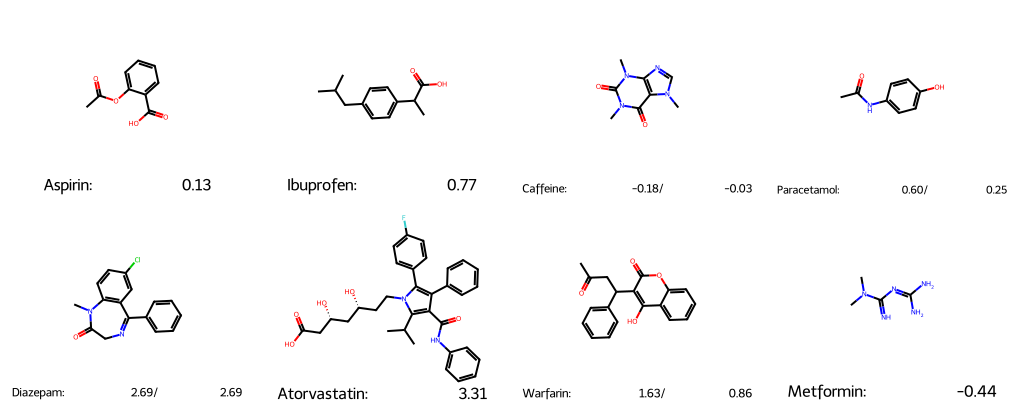

In [16]:
# 유명 약물 — logD 예측 대상. 데이터셋에 있으면 실험값과 대조.
lipo_probe = [
    ("Aspirin (아스피린)",     "CC(=O)Oc1ccccc1C(=O)O"),
    ("Ibuprofen (이부프로펜)", "CC(C)Cc1ccc(C(C)C(=O)O)cc1"),
    ("Caffeine (카페인)",      "Cn1cnc2c1c(=O)n(C)c(=O)n2C"),
    ("Paracetamol (아세트아미노펜)", "CC(=O)Nc1ccc(O)cc1"),
    ("Diazepam (디아제팜)",    "CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21"),
    ("Atorvastatin (아토르바스타틴)", "CC(C)c1c(C(=O)Nc2ccccc2)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CC[C@@H](O)C[C@@H](O)CC(=O)O"),
    ("Warfarin (와파린)",      "CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O"),
    ("Metformin (메트포르민)", "CN(C)C(=N)N=C(N)N"),
]

def _lipo_feat(m):
    return np.hstack([descriptors(m), ecfp(m)]).reshape(1, -1)   # 기술자+ECFP (학습과 동일)
lipo_lookup = {}
for s, v in zip(lipo["smiles"], lipo["target"]):
    cs = _canon(s)
    if cs is not None:
        lipo_lookup.setdefault(cs, float(v))

rows, mols, legs = [], [], []
for name, smi in lipo_probe:
    m = Chem.MolFromSmiles(smi)
    if m is None:
        continue
    pred_logd = float(reg.predict(_lipo_feat(m))[0])            # 학습된 회귀 모델의 실제 예측
    actual = lipo_lookup.get(Chem.MolToSmiles(m))               # 데이터셋 실험값(있으면)
    if actual is None:
        tag, leg = "예측만(데이터셋 외)", f"{name.split(' (')[0]}: 예측 {pred_logd:.2f}"
    else:
        tag = f"실측 {actual:.2f} (오차 {pred_logd-actual:+.2f})"
        leg = f"{name.split(' (')[0]}: 예측 {pred_logd:.2f}/실측 {actual:.2f}"
    rows.append({"약물": name, "예측 logD": round(pred_logd, 2), "데이터셋검증": tag})
    mols.append(m); legs.append(leg)

lipo_probe_df = pd.DataFrame(rows)
print("=== 실제 약물 logD7.4 예측 (예측값은 학습된 회귀 모델의 실계산값) ===")
print(lipo_probe_df.to_string(index=False))
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(255, 205),
                           legends=legs, useSVG=False)
display(img)

## 4. 요약 — 표현·모델은 같고, 엔드포인트·지표만 다르다

두 엔드포인트를 나란히 놓으면 핵심 메시지가 분명해집니다: **같은 분자 표현(RDKit 기술자 + Morgan/ECFP)과 같은 모델(랜덤포레스트)** 을 쓰되, **엔드포인트의 성격(분류 vs 회귀)에 따라 헤드와 평가지표만 교체**했을 뿐입니다.

In [17]:
summary = pd.DataFrame([
    {"엔드포인트":"BBBP (혈뇌장벽 투과)", "ADME/T 축":"Distribution/T", "문제":"분류",
     "표현":"ECFP(2048)", "모델":"RF(balanced)",
     "주지표":"ROC-AUC", "테스트":f"{bbbp_auc:.3f}", "5-fold CV":f"{bbbp_cv_auc:.3f} ± {bbbp_cv_std:.3f}",
     "보조지표":f"정확도 {bbbp_acc:.3f}"},
    {"엔드포인트":"Lipophilicity (logD7.4)", "ADME/T 축":"Absorption/Distribution", "문제":"회귀",
     "표현":"기술자+ECFP", "모델":"RF",
     "주지표":"R²/RMSE", "테스트":f"R²={lipo_r2:.3f}", "5-fold CV":f"R²={lipo_cv_r2:.3f} ± {lipo_cv_std:.3f}",
     "보조지표":f"RMSE {lipo_rmse:.3f}"},
])
print("=== ADME/T 다중 엔드포인트 성능 요약 (모두 실계산) ===")
summary


=== ADME/T 다중 엔드포인트 성능 요약 (모두 실계산) ===


,엔드포인트,ADME/T 축,문제,표현,모델,주지표,테스트,5-fold CV,보조지표
0,BBBP (혈뇌장벽 투과),Distribution/T,분류,ECFP(2048),RF(balanced),ROC-AUC,0.938,0.921 ± 0.009,정확도 0.917
1,Lipophilicity (logD7.4),Absorption/Distribution,회귀,기술자+ECFP,RF,R²/RMSE,R²=0.673,R²=0.666 ± 0.009,RMSE 0.695


/tmp/ipykernel_2933374/1325049699.py:17: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/1325049699.py:17: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/1325049699.py:17: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/1325049699.py:17: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/1325049699.py:17: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/1325049699.py:17: UserWarning: Glyph 45458 (\N{HANGUL SYLLABLE NOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2933374/1325049699.py:17: UserWa

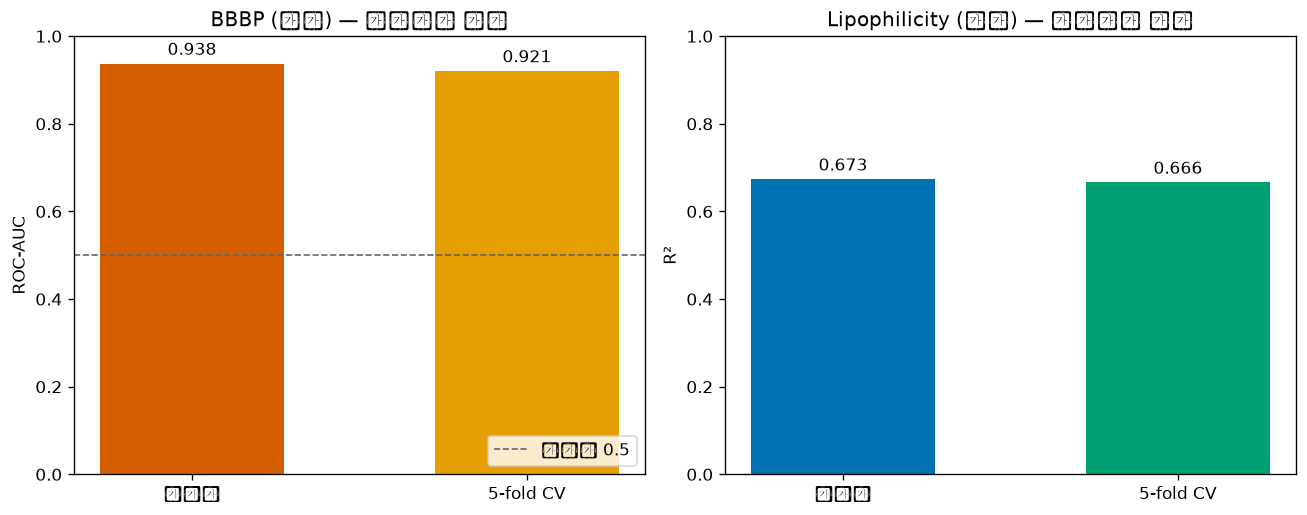

In [18]:
# 지표 스케일이 다르므로(ROC-AUC vs R²) 각 엔드포인트의 테스트 vs CV 안정성을 나란히 시각화
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
# BBBP: ROC-AUC
b_vals = [bbbp_auc, bbbp_cv_auc]
ax[0].bar(["테스트", "5-fold CV"], b_vals, color=[CB["red"], CB["orange"]], width=0.55)
ax[0].axhline(0.5, color=CB["gray"], ls="--", lw=1, label="무작위 0.5")
ax[0].set_ylim(0, 1); ax[0].set_ylabel("ROC-AUC")
ax[0].set_title("BBBP (분류) — 높을수록 좋음")
for i, v in enumerate(b_vals): ax[0].text(i, v+0.02, f"{v:.3f}", ha="center", fontsize=10)
ax[0].legend(loc="lower right")
# Lipophilicity: R²
l_vals = [lipo_r2, lipo_cv_r2]
ax[1].bar(["테스트", "5-fold CV"], l_vals, color=[CB["blue"], CB["green"]], width=0.55)
ax[1].set_ylim(0, 1); ax[1].set_ylabel("R²")
ax[1].set_title("Lipophilicity (회귀) — 높을수록 좋음")
for i, v in enumerate(l_vals): ax[1].text(i, v+0.02, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout(); plt.show()


## 5. ADME/T 전반과 공개 벤치마크 — 실무로 확장하기

이 노트북은 ADME/T의 **두 축**만 다뤘지만, 실무에서는 다섯 축 전반을 여러 엔드포인트로 관리합니다.

| 축 | 대표 엔드포인트 예시 | 문제 유형 |
|---|---|---|
| **A — 흡수** | Caco-2 투과도, 경구 생체이용률, 용해도, **친유성(logD)** | 회귀·분류 |
| **D — 분포** | **혈뇌장벽 투과(BBBP)**, 혈장단백결합(PPB), 분포용적 | 분류·회귀 |
| **M — 대사** | CYP450 억제/기질(1A2·2C9·2D6·3A4), 대사 안정성 | 분류·회귀 |
| **E — 배설** | 클리어런스, 반감기 | 회귀 |
| **T — 독성** | hERG 심독성, 간독성(DILI), Ames 변이원성, LD50 | 분류·회귀 |

**핵심은 오늘 본 그대로입니다** — 축과 엔드포인트가 무엇이든, "**SMILES → 표현(기술자/지문) → 모델 → 엔드포인트별 지표로 평가**"라는 파이프라인은 동일합니다. 바뀌는 것은 (1) 레이블(데이터), (2) 헤드(분류기/회귀기), (3) 평가지표뿐입니다.

**대표 공개 벤치마크 (실재)**
- **MoleculeNet** (Wu et al. 2018): BBBP·Lipophilicity·ESOL·Tox21·ClinTox 등 분자 물성/ADMET 표준 벤치마크 모음. 오늘 쓴 두 데이터셋의 출처.
- **TDC (Therapeutics Data Commons)** (Huang et al. 2021): ADME·Tox 다수 엔드포인트를 통일된 로더/분할/리더보드로 제공 (`pip install PyTDC`). 실무에서 다중 엔드포인트를 체계적으로 벤치마킹할 때 표준.

> ⚠️ **교육용 데모입니다.** 실제 ADME/T 모델링은 **scaffold split**(무작위 분할이 아닌 골격 기반 분할로 낙관 편향 제거), 외부 검증셋, 더 큰 데이터, 예측 **불확실성 정량**, 그리고 무엇보다 **실험 검증**이 필요합니다. in silico 예측은 실험으로 확인되기 전까지 결론이 아니라 우선순위 지정 도구입니다.

**참고문헌 (실재)**
- Martins, I. F. et al. *A Bayesian Approach to in Silico Blood-Brain Barrier Penetration Modeling.* J. Chem. Inf. Model. **52**, 1686–1697 (2012). — BBBP
- Wu, Z. et al. *MoleculeNet: A Benchmark for Molecular Machine Learning.* Chem. Sci. **9**, 513–530 (2018). — Lipophilicity·BBBP 벤치마크 출처
- Huang, K. et al. *Therapeutics Data Commons: Machine Learning Datasets and Tasks for Drug Discovery and Development.* NeurIPS Datasets and Benchmarks (2021). — TDC
- Rogers, D. & Hahn, M. *Extended-Connectivity Fingerprints.* J. Chem. Inf. Model. **50**, 742–754 (2010). — ECFP/Morgan
- RDKit: Open-source cheminformatics (https://www.rdkit.org)